# Universidad Nacional Autonoma de México
# Facultad de Estudios Superiores Aragon
## Analisis exploratorio

### De la paz Sarabia Marcela
### Moran Sanchez Gerardo Jasel
### Simón Cruz Humberto

## Mineria de datos
## Prof. Mendoza Gonzalez Omar


# Carga del Dataset

### Cargamos el dataset desde la URL proporcionada y este lo almacenamos en un Dataframe el cual llamamos "dfv".
### Despues llamamos al Dataframe y lo desplegamos para ver el contenido de este mismo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

dfv = pd.read_csv("https://raw.githubusercontent.com/omarmendoza564/datos/main/datos/aerolineas.csv")
dfv

#Mostramos todo el contenido de los datos que tenemos y lo asignamos a dfv

,nrow,id,dia,aerolinea,destino,region,dest_size,area_abordaje,fecha_salida,espera_min,limpieza,seguridad,satisfaccion
0,0,1351,martes,UNITED INTL,KANSAI,Asia,Hub,Gates 91-102,2018-12-31,115.0,Limpio,Neutral,Muy satisfecho
1,1,373,viernes,ALASKA,SAN JOSE DEL CABO,Canada / Mexico,Small,Gates 50-59,2018-12-31,135.0,Limpio,Muy seguro,Muy satisfecho
2,2,2820,jueves,DELTA,LOS ÁNGELES,oeste de EE. UU.,Hub,Gates 40-48,2018-12-31,70.0,Promedio,Algo seguro,Neutral
3,3,1157,martes,SUDOESTE,LOS ÁNGELES,oeste de EE. UU.,Hub,Gates 20-39,2018-12-31,190.0,Limpio,Muy seguro,Algo satisfecho
4,4,2992,miércoles,AMERICAN,MIAMI,East US,Hub,Gates 50-59,2018-12-31,559.0,Inaceptable,Muy seguro,Algo satisfecho
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475,2804,1475,martes,ALASKA,NUEVA YORK-JFK,este de EE. UU.,Hub,Gates 50-59,2018-12-31,280.0,Algo limpio,Neutral,Algo satisfecho
2476,2805,2222,jueves,SUDOESTE,PHOENIX,oeste de EE. UU.,Hub,Gates 20-39,2018-12-31,165.0,Limpio,Muy seguro,Muy satisfecho
2477,2806,2684,viernes,UNITED,ORLANDO,Este de EE. UU.,Hub,Gates 70-90,2018-12-31,92.0,Limpio,Muy seguro,Muy satisfecho
2478,2807,2549,martes,JETBLUE,LONG BEACH,oeste de EE. UU.,Small,Gates 1-12,2018-12-31,95.0,Limpio,Algo seguro,Muy satisfecho


# Analisis exploratorio
### Dividimos nuestras variables en Categoricas y numericas, siendo "nrow", "id", "espera_min" nuestras **variables numericas** y "dia", "aerolinea", "destino", "region", "dest_size", "area_abordaje", "fecha_salida", "limpieza", "seguridad" y "satisfaccion" nuestras **varianles categoricas**.

In [ ]:
variables_numericas = ['nrow', 'id', 'espera_min']
variables_categoricas = ['dia', 'aerolinea', 'destino', 'region', 'dest_size', 'area_abordaje', 'fecha_salida', 'limpieza', 'seguridad', 'satisfaccion']

### Procedemos a sacar el promedio, la mediana y despues desplegar un resumen estadistico de nuestras variables numericas

In [ ]:
#Sacamos el promedio (mean)

dfv[variables_numericas].mean()

,0
nrow,1410.849597
id,1812.204032
espera_min,166.372676


In [ ]:
#Sacamos la mediana

dfv[variables_numericas].median()

,0
nrow,1412.5
id,1857.5
espera_min,145.0


In [ ]:
dfv[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
nrow,2480.0,1410.849597,815.252563,0.0,706.75,1412.5,2121.25,2808.0
id,2480.0,1812.204032,945.389975,1.0,1035.75,1857.5,2580.25,9004.0
espera_min,2474.0,166.372676,107.582681,15.0,105.00,145.0,189.25,1365.0


### De nuestras variables numericas, tomamos **"espera_min"** y procedemos a sacar los datos que estan en el Percentil 75, lo que significa que los datos que  estan por debajo o sean iguales al 75%

In [ ]:
dfv[dfv['espera_min'] <= dfv['espera_min'].quantile(0.75)].count()

,0
nrow,1855
id,1855
dia,1855
aerolinea,1855
destino,1855
region,1855
dest_size,1855
area_abordaje,1855
fecha_salida,1855
espera_min,1855


### Ahora procedemos a sacar la mediana de **"espera_min"**, despues obtenemos su resumen estadistico en la cual podemos comprobar los datos obtenidos previamente donde vemos que 166 es el rpomedio, la mitad de los datos (mediana) es 145

In [ ]:
dfv['espera_min'].quantile(0.50)

145.0

In [ ]:
dfv.espera_min.describe()

,espera_min
count,2474.000000
mean,166.372676
std,107.582681
min,15.000000
25%,105.000000
50%,145.000000
75%,189.250000
max,1365.000000


# Histograma
## Este tipo de grafico nos ayuda a ver  la distribucion de nuestras variables numerica, nos mostrara la frecuencia con la que los valores de la variable caen dentro de determinados intervalos (**"bins"**).

# Histograma de nrow
### Tenemos una distribucion de los datos uniforme, no tenemos dato atipicos, para prueba de ello es la curva azul que se nos muestra algo plana dandonos a entender la uniformidad de la distribucion de los datos.

# Histograma de id
### Acomparacion del histograma anterior aqui podemos ver que si tenemos un dato aislado, podemos intuir que es un dato atipico o uno mal capturado, con datos cargados hacia la izquierda, encuanto a la linea azul nos da picos entre 1000 y 3000 para despues caer abruptamente, aqui no tenemos datos uniformes ni una buena distribucion en id

# Histograma de espera_min
### Tenemos un caso similar con la anterior solo aqui no hay datos atipicos, vemos una distribucion de los datos cargada hacia la izquierda y un decremento bastante considerable hacia la derecha, tenemos un pico entre 100 y 200 minutos de espera, podemos expresar en este histograma que a mayor numero de minutos de espra, menor son los datos capturados y a menor numero de minutos de espera, mayor son los numeros capturados.
### Podemos resumir aqui que es mas comun esperar menos para abordar o que es menos comun esperar mas tiempo para abordar.



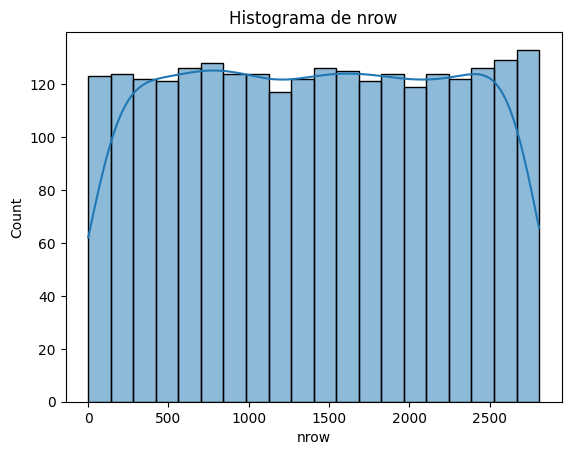

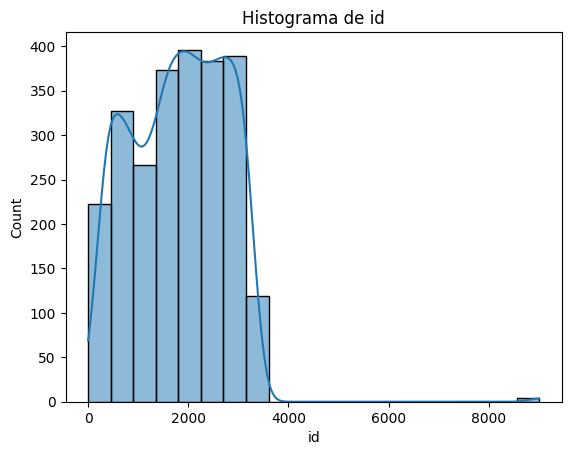

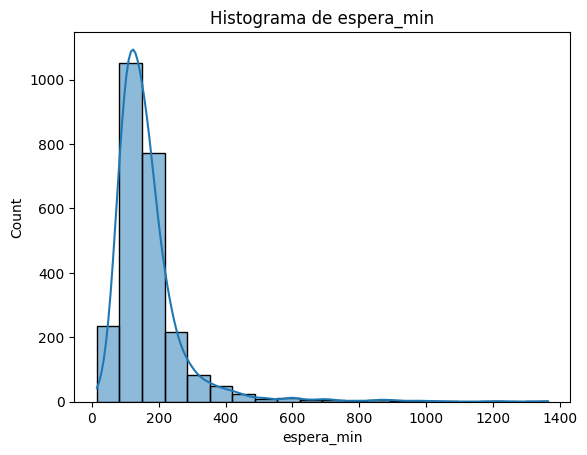

In [ ]:
for v in variables_numericas:
   sns.histplot(dfv[v], kde=True, bins=20)
   plt.title(f"Histograma de {v}")
   plt.show()

# Analisis de variables categoricas

#### Tras realizar el analisis nos dimos cuenta de que hay algunos datos que son muy similares entre si, o que son lo mismo pero abreviado, en otro idioma o con letras mayusculas, asi que realizaremos la union de estos datos y aprovechando su modificacion los volveremos una variable ordinal, es decir que tiene numeros y nos dan una jerarquizacion

## Grafica Distribucion de destino
###  Tenemos carios destinos bastantes populares para ir siendo los 4 mas concurridos **PARIS-DE GAULLE**, seguido de **Los Angeles** y por ultimo **Denver** y **Hong Kong** con la misma cantidad de viajes registrados
### los 3 destinos menos visitados son **EUGENE**, **Dallas** y **New York**

## Grafica de Distribucion area_abordaje
### En cuanto al area de abordaje, es menos comun que las personas aborden por las puertas de la **60** a **69**, teniendo buena afluencia pero no la necesaria para ser una de las mas concurridas, probablemente estas zonas de abordar seran para los vuelos a destinos poco visitados. Mientras que si hablamos de las mas concurridas estas son de las puertas **1** a la **12**, añadiendo que las puestas **90** a la **102** y **50** a la **59** tambien son de bastante afluencia.

## Grafica de Distribucion fecha_salida
### Podemos decir sin temos a equivocarnos que el mayor numero de vuelos salieron en la fecha **2018-12-31** siendo una diferencia bastante grande con la fecha del **2018-01-01**. Esto nos deja como conclucion que para año nuevo hubo una cantidad bastante grande salio de viaje ese dia, mientras que el dia siguiente muy pocas personas tomaron un vuelo.


frecuencia de dia
dia
martes       534
miércoles    519
jueves       488
viernes      368
sábado       210
domingo      162
Domingo       89
lunes         59
Lunes         32
Sunday        16
Thursday       1
​​martes       1
Friday         1
Name: count, dtype: int64


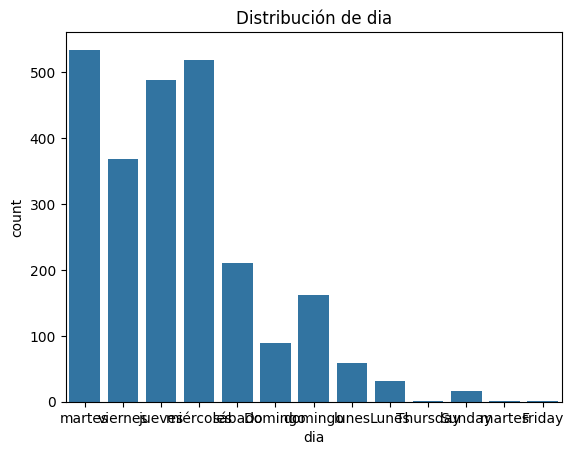

frecuencia de aerolinea
aerolinea
UNITED                 524
ALASKA                 316
SUDOESTE               182
AMERICAN               175
DELTA                  170
UNITED INTL            155
JETBLUE                144
AIR CANADA             133
AIR FRANCE / KLM       120
CATHAY PACIFIC          82
LUFTHANSA               64
FRONTIER                41
EMIRATES                39
WOW                     38
VIRGIN ATLANTIC         32
TURKISH AIRLINES        30
QANTAS                  28
AIR NEW ZEALAND         21
BRITISH AIRWAYS         21
AER LINGUS              18
INTERJET                18
COPA                    16
SINGAPORE AIRLINES      16
PHILIPPINE AIRLINES     14
HAWAIIAN AIR            13
ESTE DE CHINA           13
KOREAN AIR              12
AEROMEXICO              11
EVA AIR                 10
AIR CHINA                8
AVIANCA                  6
CHINA SUR                2
SUROESTE                 2
SUR DE CHINA             2
ANA ALL NIPPON           2
UNIDOS               

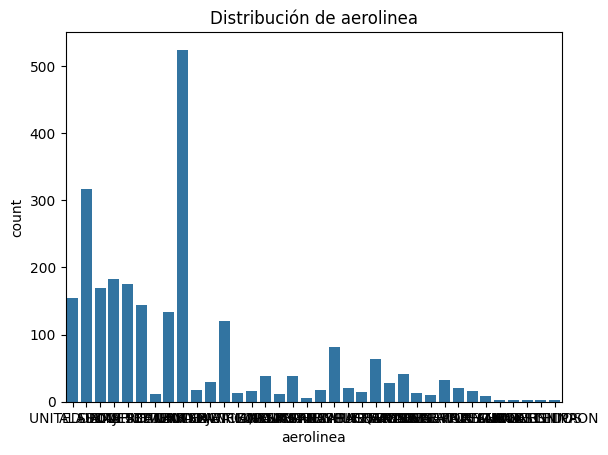

frecuencia de destino
destino
PARIS-DE GAULLE            126
LOS ÁNGELES                115
DENVER                      96
HONG KONG                   96
LONDON HEATHROW             91
                          ... 
NUEVA ORLEANS                3
QINGDAO                      3
NEW YORK-JFK                 2
DALLAS-FT. VALE LA PENA      1
EUGENE                       1
Name: count, Length: 77, dtype: int64


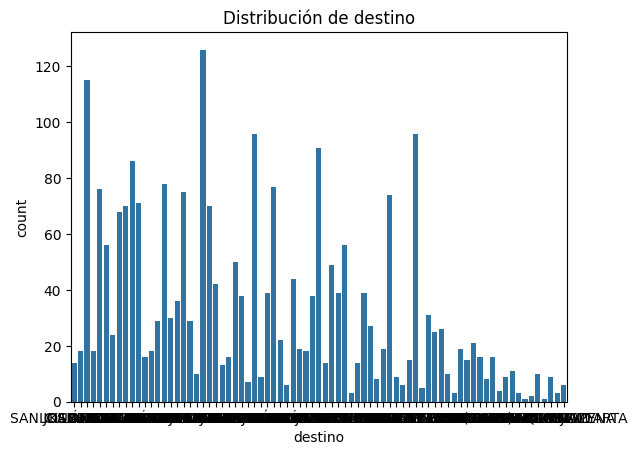

frecuencia de region
region
oeste de EE. UU.              658
Europa                        272
Asia                          227
este de EE. UU.               200
Canadá / México               191
Midwest US                    126
Medio Oeste de EE. UU.        114
West US                       108
Oeste de EE. UU.               99
Este de EE. UU.                86
East US                        81
eur                            79
Australia / Nueva Zelanda      60
Medio Oriente                  47
EAST US                        39
oriente medio                  19
Centroamérica / Sudamérica     17
ESTE DE EE. UU.                17
ESTE de EE. UU.                13
Medio oeste de EE. UU.         10
Canada / Mexico                 8
Centro / Sudamérica             5
Medio oriente                   2
Medio Oeste de los EE. UU.      1
Oriente Medio                   1
Name: count, dtype: int64


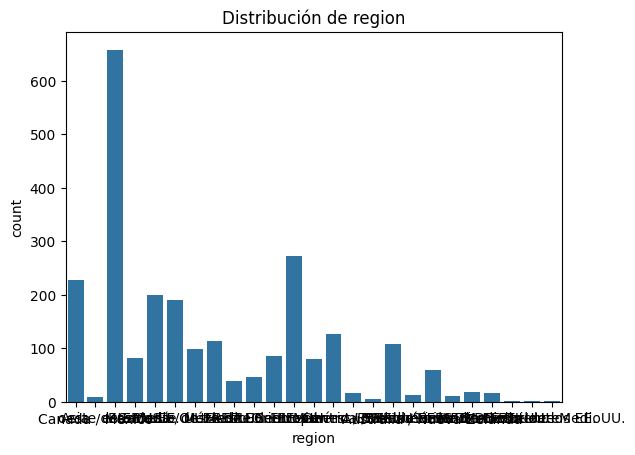

frecuencia de dest_size
dest_size
Hub         1124
Medium       601
  Hub        427
Small        151
Grande        85
   Small      50
Large         24
grande        18
Name: count, dtype: int64


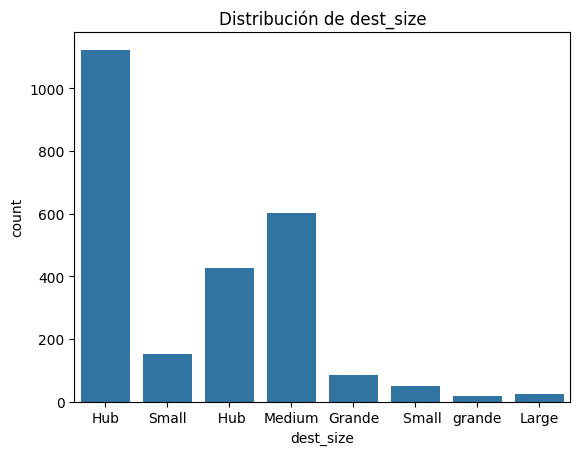

frecuencia de area_abordaje
area_abordaje
Gates 1-12      611
Gates 91-102    474
Gates 50-59     468
Gates 70-90     383
Gates 20-39     225
Gates 40-48     176
Gates 60-69     143
Name: count, dtype: int64


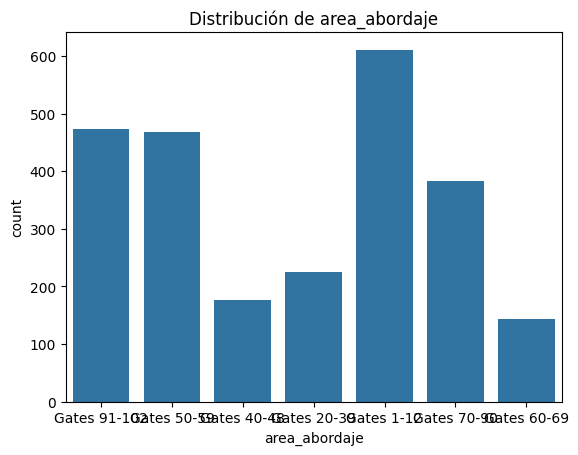

frecuencia de fecha_salida
fecha_salida
2018-12-31    2443
2018-01-01      37
Name: count, dtype: int64


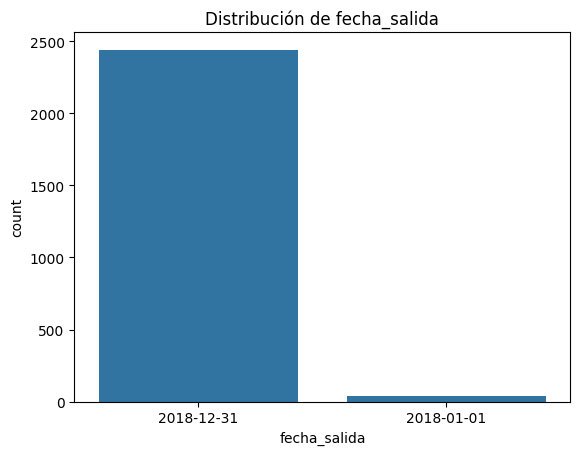

frecuencia de limpieza
limpieza
Algo limpio    1177
Limpio          885
Promedio        380
Algo sucio       26
Medio             9
Sucio             2
Inaceptable       1
Name: count, dtype: int64


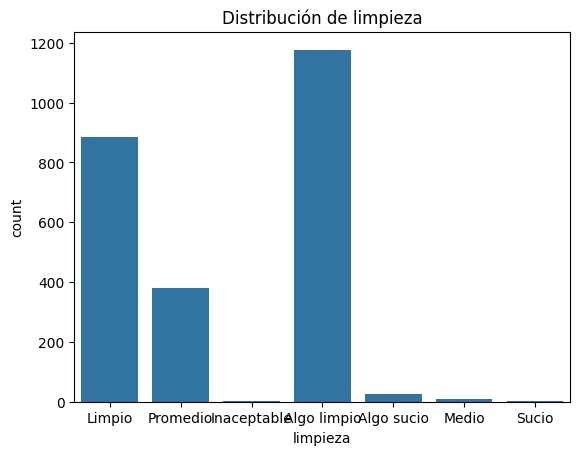

frecuencia de seguridad
seguridad
Muy seguro       1298
Algo seguro       865
Neutral           303
Muy inseguro        8
Algo inseguro       6
Name: count, dtype: int64


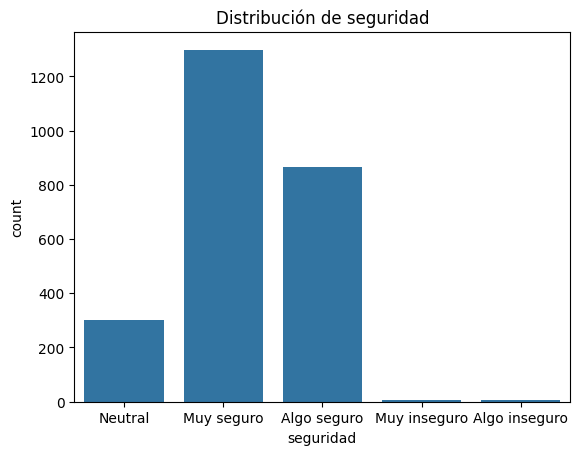

frecuencia de satisfaccion
satisfaccion
Algo satisfecho      1351
Muy satisfecho        596
Neutral               487
Algo insatisfecho      42
Muy insatisfecho        4
Name: count, dtype: int64


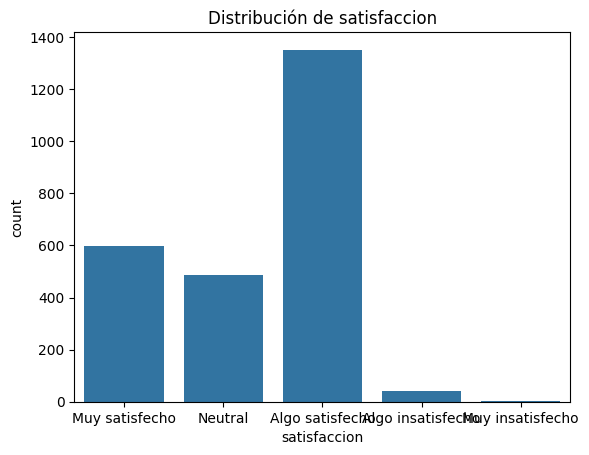

In [ ]:
for v in variables_categoricas:
    print(f"frecuencia de {v}")
    print(dfv[v].value_counts())

    sns.countplot(x=v,data=dfv)
    plt.title(f"Distribución de {v}")
    plt.show()

# Codigo para unir datos que eran similares pero con diferencias de idioma o mayusculas

### Tambien agregamos una funcion que pasa el nombre a minusculas o mayusculas segun el caso para tener un orden general y poder hacer un mejor analisis



In [ ]:

dfv['dia'] = dfv['dia'].replace({'Sunday': 'domingo'})
dfv['dia'] = dfv['dia'].replace({'Thursday': 'jueves'})
dfv['dia'] = dfv['dia'].replace({'Friday': 'viernes'})
dfv['dia'] = dfv['dia'].replace({'​​martes': 'martes'})
dfv['dia'] = dfv['dia'].str.lower()

# Codigo para identificar el dato sezgado en dia

In [ ]:
#print(f"frecuencia de dias")
#print(dfv['dia'].value_counts())
#sns.countplot(x='dia',data=dfv)

frecuencia_dias = dfv['dia'].value_counts()
for dia, frecuencia in frecuencia_dias.items():
    indices = dfv[dfv['dia'] == dia].index.tolist()
    print(f"'{dia}' aparece {frecuencia} veces en los índices: {indices}")

#ahora que conocemos su indice, lo usamos para mostrar todos los datos que tiene
fila_filtrada = dfv.loc[711]

# Mostrar la fila filtrada
print(fila_filtrada)

'martes' aparece 535 veces en los índices: [0, 3, 9, 10, 12, 14, 16, 20, 21, 24, 26, 27, 30, 39, 41, 45, 50, 54, 67, 68, 72, 77, 85, 86, 88, 103, 106, 109, 110, 111, 112, 123, 136, 137, 149, 153, 159, 163, 165, 168, 171, 173, 182, 184, 186, 191, 203, 216, 217, 218, 225, 229, 232, 244, 256, 263, 267, 273, 276, 279, 285, 294, 297, 301, 302, 307, 315, 330, 331, 333, 334, 338, 343, 350, 367, 371, 376, 378, 379, 391, 392, 400, 401, 402, 406, 414, 420, 422, 429, 434, 435, 443, 446, 452, 454, 459, 460, 463, 469, 475, 476, 477, 488, 491, 494, 496, 502, 520, 525, 528, 532, 533, 539, 541, 542, 543, 545, 549, 550, 557, 563, 565, 566, 574, 575, 591, 595, 609, 610, 619, 621, 622, 625, 628, 634, 640, 643, 645, 648, 651, 655, 657, 658, 664, 666, 670, 673, 674, 679, 685, 692, 697, 704, 708, 710, 711, 714, 721, 724, 745, 746, 750, 757, 761, 765, 766, 767, 768, 781, 789, 793, 796, 799, 801, 808, 809, 814, 817, 824, 825, 828, 838, 846, 847, 851, 856, 857, 870, 873, 877, 878, 880, 885, 890, 898, 906, 910,

# Tabla Dias

# Distribucion de dia (Dias fucionados)
### De los 7 dias de la semana podemos concluir que los dias Martes, Miercoles, Jueves y Viernes son los dias con mayor afluencia o mayor numero de vuelos registrados, siendo el Viernes el mas bajo de estos dias.
### Correspondiente al resto de dias: Sabado, Domiengo y Lunes; tienen una baja considerable con respecto a los dias anteriores por lo que podemos decir que son dias en los cuales no hay muchos vuelos o que no son los dias mas comunes en los que la gente suele viajar de un destino a otro.

frecuencia de dias
dia
martes       535
miércoles    519
jueves       489
viernes      369
domingo      267
sábado       210
lunes         91
Name: count, dtype: int64


<Axes: xlabel='dia', ylabel='count'>

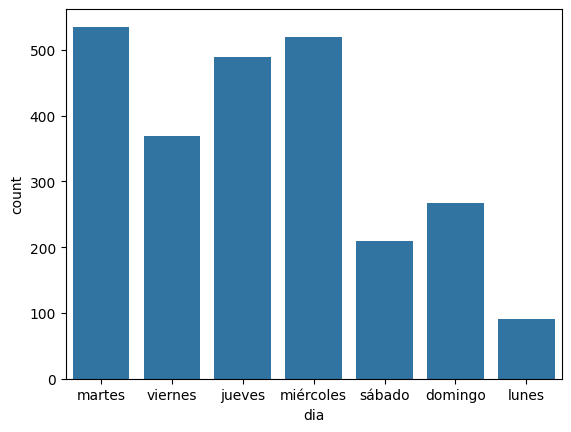

In [ ]:
print(f"frecuencia de dias")
print(dfv['dia'].value_counts())
sns.countplot(x='dia',data=dfv)

# Tabla Satisfaccion

### Tenemos una serie de datos cualitativos categoricos ordinales, es decir que tienen una jerarquizacion, como en el caso de "satisfaccion" donde los datos como "muy satisfecho" o "muy insatisfecho" tienen una diferencia considerable de jerarquia, asi que para que podamos trabajar con ellos los transformaremos a cuantitativos numericos.

### Podemos concluir con este grafico de la mayoria de los vuelos tienen una calificacion buena pero no excelente, teniendo una buena satisfaccion en la mayoria de los vuelos siendo nuestro pico el numero **4** significa **Algo satisfecho**.

frecuencia de satisfaccion
satisfaccion
4    1351
5     596
3     487
2      42
1       4
Name: count, dtype: int64


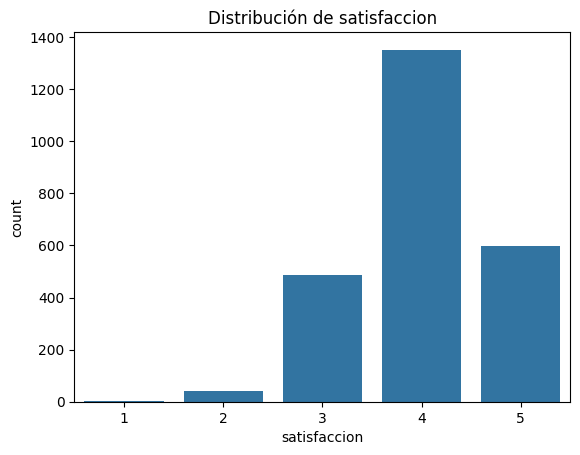

In [ ]:
dfv['satisfaccion'] = dfv['satisfaccion'].replace({'Muy satisfecho': 5})
dfv['satisfaccion'] = dfv['satisfaccion'].replace({'Algo satisfecho': 4})
dfv['satisfaccion'] = dfv['satisfaccion'].replace({'Neutral': 3})
dfv['satisfaccion'] = dfv['satisfaccion'].replace({'Algo insatisfecho': 2})
dfv['satisfaccion'] = dfv['satisfaccion'].replace({'Muy insatisfecho': 1})


print(f"frecuencia de satisfaccion")
print(dfv['satisfaccion'].value_counts())

sns.countplot(x='satisfaccion',data=dfv)
plt.title(f"Distribución de satisfaccion")
plt.show()


# Tabla Satisfaccion con la Seguridad

### Para que podamos trabajar con ellos transformaremos los datos de cualitativos categoricos ordinales a cuantitativos numericos.

### La tabla nos muestra una distribucion mas cargada a la derecha que son los numeros 4 y 5 que corresponden a **Algo seguro** y **Muy seguro**, podemos decir que la seguridad en los vuelos en muy buena, teniendo como algo inusual que los incidentes pasen, no nulos, ya que hay datos registrados en las otras opciones.

frecuencia de seguridad
seguridad
5    1298
4     865
3     303
1       8
2       6
Name: count, dtype: int64


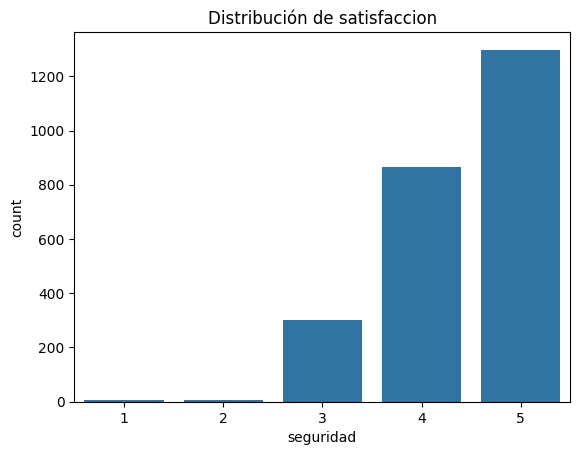

In [ ]:
#seguridad
#Muy seguro       1298
#Algo seguro       865
#Neutral           303
#Muy inseguro        8
#Algo inseguro       6
dfv['seguridad'] = dfv['seguridad'].replace({'Muy seguro': 5})
dfv['seguridad'] = dfv['seguridad'].replace({'Algo seguro': 4})
dfv['seguridad'] = dfv['seguridad'].replace({'Neutral': 3})
dfv['seguridad'] = dfv['seguridad'].replace({'Algo inseguro': 2})
dfv['seguridad'] = dfv['seguridad'].replace({'Muy inseguro': 1})

print(f"frecuencia de seguridad")
print(dfv['seguridad'].value_counts())

sns.countplot(x='seguridad',data=dfv)
plt.title(f"Distribución de {v}")
plt.show()

# Tabla Satisfaccion con la Limpieza

### Para que podamos trabajar con ellos transformaremos los datos de cualitativos categoricos ordinales a cuantitativos numericos.

### Los datos estan cargados hacia la derecha siendo el rubro mas alto el numero **"6"** que significa **Algo limpio** y el nuero **"7"** (**Limpio**) con un diferencia no tan considerable.
### En resumen, son mucho menos los vuelos que carecen de una limpieza en sus instalaciones, teniendo una tendencia a que el avion siempre este limpio y en buen estado.

frecuencia de limpieza
limpieza
6    1177
7     885
5     380
3      26
4       9
2       2
1       1
Name: count, dtype: int64


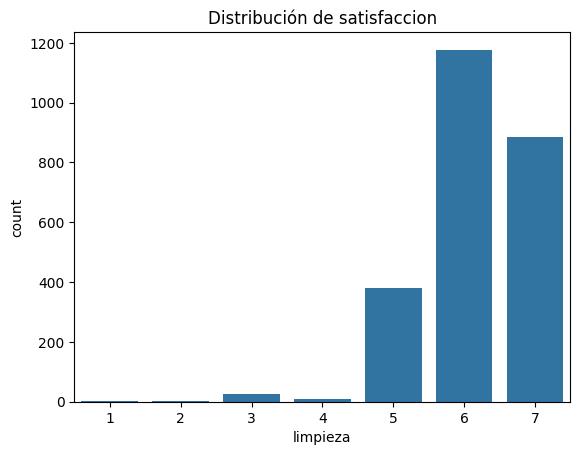

In [ ]:
#limpieza
#Algo limpio    1177
#Limpio          885
#Promedio        380
#Algo sucio       26
#Medio             9
#Sucio             2
#Inaceptable       1
dfv['limpieza'] = dfv['limpieza'].replace({'Limpio': 7})
dfv['limpieza'] = dfv['limpieza'].replace({'Algo limpio': 6})
dfv['limpieza'] = dfv['limpieza'].replace({'Promedio': 5})
dfv['limpieza'] = dfv['limpieza'].replace({'Medio': 4})        #promedio y medio se fusionan?
dfv['limpieza'] = dfv['limpieza'].replace({'Algo sucio': 3})
dfv['limpieza'] = dfv['limpieza'].replace({'Sucio': 2})
dfv['limpieza'] = dfv['limpieza'].replace({'Inaceptable': 1})

print(f"frecuencia de limpieza")
print(dfv['limpieza'].value_counts())

sns.countplot(x='limpieza',data=dfv)
plt.title(f"Distribución de {v}")
plt.show()

# Tabla Distribucion dest_size

### Aqui tambien hay datos repetidos o que significan lo mismo asi que los vamos a unir y los cambiarlos anumericos tambien

### Para esta grafica, vemos el pico de datos esta en el rubro **"1"** (**Hub**) por lo que este es el mas elegido por los usuarios que las demas opciones junto con una distribucion bastante grande en comparacion a las otras posibles opciones

frecuencia de dest_size
dest_size
1    1551
3     601
2     201
4     127
Name: count, dtype: int64


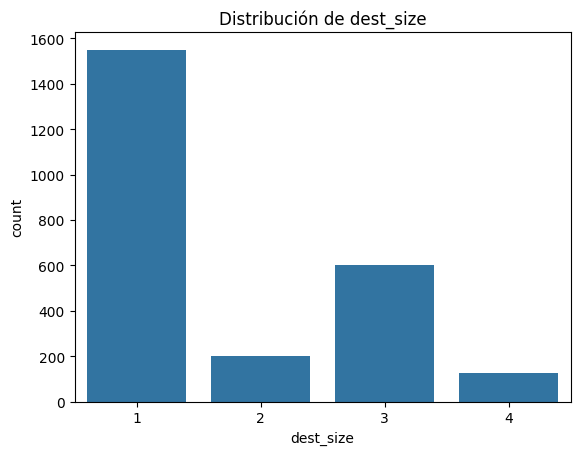

In [ ]:
#frecuencia de dest_size
#dest_size
#Hub         1124 {1
#Medium       601 {3}
#  Hub        427 {1
#Small        151 {2
#Grande        85 {4}
#   Small      50 {2
#Large         24 {4}
#grande        18 {4}


dfv['dest_size'] = dfv['dest_size'].replace({'Hub': 1})
dfv['dest_size'] = dfv['dest_size'].replace({'  Hub ': 1})
dfv['dest_size'] = dfv['dest_size'].replace({'Small': 2})
dfv['dest_size'] = dfv['dest_size'].replace({'   Small': 2})
dfv['dest_size'] = dfv['dest_size'].replace({'Medium': 3})
dfv['dest_size'] = dfv['dest_size'].replace({'Grande': 4})
dfv['dest_size'] = dfv['dest_size'].replace({'grande': 4})
dfv['dest_size'] = dfv['dest_size'].replace({'Large': 4})

print(f"frecuencia de dest_size")
print(dfv['dest_size'].value_counts())

sns.countplot(x='dest_size',data=dfv)
plt.title(f"Distribución de dest_size")
plt.show()

# Distribucion de Aerolineas
### Igual que antes algunos datos se repiten con diferencias ortograficas o de traduccion, pero en este caso solamente las agruparemos y se mantendran como  Cualitativos Categoricos Nominales

### La aerolinia UNITED es  la que mas tiene con mucha direfencias a las demas, por lo que podemos decir que es una de las favoritas con mucho margen en comparacion de las demas, despues tenemos a Alaska que igual tiene una distribucion abundante que le permite separarce de las demas, las cuales tienen mucho menos frecuencia como se ve en la grafica, mostrandonos a las aerolineas chinas como las menos usadas o menos populares

frecuencia de aerolinea
aerolinea
UNITED                 681
ALASKA                 316
SUDOESTE               184
AMERICAN               175
DELTA                  170
JETBLUE                144
AIR CANADA             133
AIR FRANCE / KLM       120
CATHAY PACIFIC          82
LUFTHANSA               64
FRONTIER                41
EMIRATES                39
WOW                     38
VIRGIN ATLANTIC         32
TURKISH AIRLINES        30
QANTAS                  28
AIR NEW ZEALAND         21
BRITISH AIRWAYS         21
INTERJET                18
AER LINGUS              18
SINGAPORE AIRLINES      16
COPA                    16
PHILIPPINE AIRLINES     14
ESTE DE CHINA           13
HAWAIIAN AIR            13
KOREAN AIR              12
AEROMEXICO              11
EVA AIR                 10
AIR CHINA                8
AVIANCA                  6
CHINA SUR                4
ANA ALL NIPPON           2
Name: count, dtype: int64


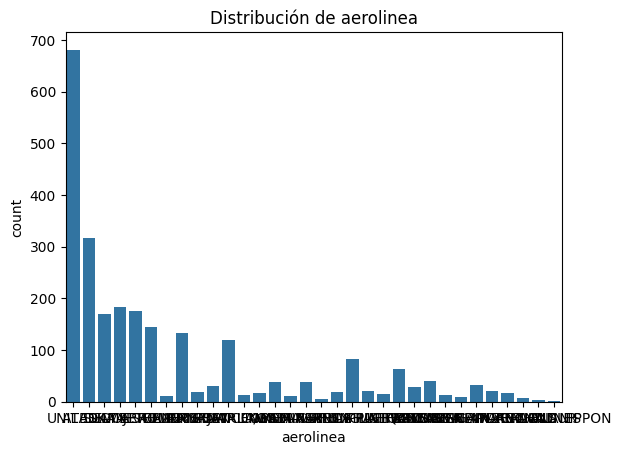

In [ ]:
#aerolinea
#UNITED                 524 /
#ALASKA                 316 /
#SUDOESTE               182 /
#AMERICAN               175 /
#DELTA                  170 /
#UNITED INTL            155 //mismo que united
#JETBLUE                144 /
#AIR CANADA             133 /
#AIR FRANCE / KLM       120 /
#CATHAY PACIFIC          82
#LUFTHANSA               64
#FRONTIER                41
#EMIRATES                39
#WOW                     38
#VIRGIN ATLANTIC         32
#TURKISH AIRLINES        30
#QANTAS                  28
#AIR NEW ZEALAND         21
#BRITISH AIRWAYS         21
#AER LINGUS              18
#INTERJET                18
#COPA                    16
#SINGAPORE AIRLINES      16
#PHILIPPINE AIRLINES     14
#HAWAIIAN AIR            13
#ESTE DE CHINA           13
#KOREAN AIR              12
#AEROMEXICO              11
#EVA AIR                 10
#AIR CHINA                8
#AVIANCA                  6
#CHINA SUR                2
#SUROESTE                 2 //mismo que SUDOESTE
#SUR DE CHINA             2 //mismo que CHINA SUR
#ANA ALL NIPPON           2
#UNIDOS                   2 //mismo que united


dfv['aerolinea'] = dfv['aerolinea'].replace({'UNITED INTL': 'UNITED'})
dfv['aerolinea'] = dfv['aerolinea'].replace({'UNIDOS': 'UNITED'})
dfv['aerolinea'] = dfv['aerolinea'].replace({'SUROESTE': 'SUDOESTE'})
dfv['aerolinea'] = dfv['aerolinea'].replace({'SUR DE CHINA': 'CHINA SUR'})


print(f"frecuencia de aerolinea")
print(dfv['aerolinea'].value_counts())

sns.countplot(x='aerolinea',data=dfv)
plt.title(f"Distribución de aerolinea")
plt.show()


# Distribucion de Region

### Igual que antes algunos datos se repiten con diferencias ortograficas o de traduccion, pero en este caso solamente las agruparemos y se mantendran como  **Cualitativos Categoricos Nominales**.

### Las region mas popular con mucha diferencia es **"Oeste de EE.UU"**  con una diferencia bastante grande en comparacion a las demas, ahora bien, la region menos visitada o puesta como destino es la **"Sudamericana"**, **Nueva Zelanda** y **Medio Oriente**.


frecuencia de region
region
OESTE DE EE. UU.             865
ESTE DE EE. UU.              436
EUROPA                       351
MEDIO OESTE DE EE. UU.       251
ASIA                         227
CANADÁ / MÉXICO              199
MEDIO ORIENTE                 69
AUSTRALIA / NUEVA ZELANDA     60
CENTRO / SUDAMÉRICA           22
Name: count, dtype: int64


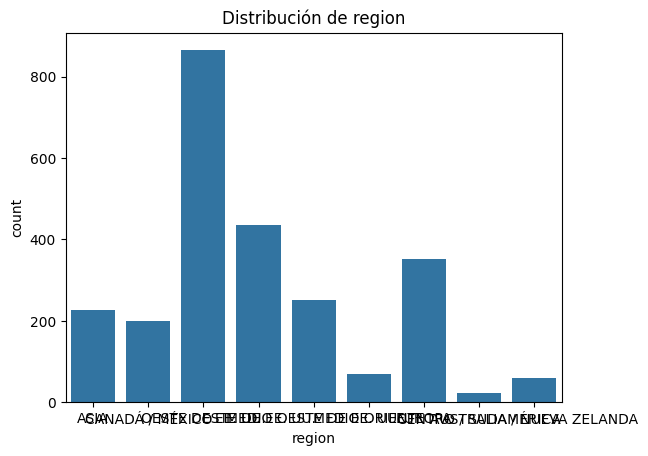

In [ ]:
#region

#oeste de EE. UU.              658
#Europa                        272
#Asia                          227
#este de EE. UU.               200
#Canadá / México               191
#Midwest US                    126
#Medio Oeste de EE. UU.        114 //mismo que Midwest US//
#West US                       108 // mismo que oeste eeuu//
#Oeste de EE. UU.               99 //MISMO QUE OESTE ee, uu
#Este de EE. UU.                86
#East US                        81 //mismo que este de eeuu
#eur                            79 //mismo que europa
#Australia / Nueva Zelanda      60 //
#Medio Oriente                  47
#EAST US                        39 //mismo que este de EEUU
#oriente medio                  19 //Mismo que Medio Oriente
#Centroamérica / Sudamérica     17
#ESTE DE EE. UU.                17 //mismo que este de EEUU
#ESTE de EE. UU.                13 //mismo que este de EEUU
#Medio oeste de EE. UU.         10 //MISMO QUE MIDWEST US
#Canada / Mexico                 8 //MISMO QUE canada mexico
#Centro / Sudamérica             5 //mismo que centroamerica sudamerica
#Medio oriente                   2 mismo que Medio Oriente
#Medio Oeste de los EE. UU.      1 mismo que midwest
#Oriente Medio                   1 mismo que medio oriente

dfv['region'] = dfv['region'].str.upper()
#filtramos todo en minusculas

#OESTE DE EE. UU.              757 /
#ESTE DE EE. UU.               316 /
#EUROPA                        272 /
#ASIA                          227 /
#CANADÁ / MÉXICO               191 /
#MIDWEST US                    126
#MEDIO OESTE DE EE. UU.        124 /mismo que midwest/
#EAST US                       120 /mismo que este de eu/
#WEST US                       108 /mismo que oeste/
#EUR                            79 /mismo que europa/
#AUSTRALIA / NUEVA ZELANDA      60
#MEDIO ORIENTE                  49
#ORIENTE MEDIO                  20 /mismo que medio oriente/
#CENTROAMÉRICA / SUDAMÉRICA     17
#CANADA / MEXICO                 8 //mismo que arriba 191 pero con tilde/
#CENTRO / SUDAMÉRICA             5 /mismo que centroamerica sudamerica/
#MEDIO OESTE DE LOS EE. UU.      1 /mismo que midwest/

dfv['region'] = dfv['region'].replace({'MEDIO OESTE DE EE. UU.': 'MIDWEST US'})
dfv['region'] = dfv['region'].replace({'WEST US': 'OESTE DE EE. UU.'})
dfv['region'] = dfv['region'].replace({'EAST US': 'ESTE DE EE. UU.'})
dfv['region'] = dfv['region'].replace({'EUR': 'EUROPA'})
dfv['region'] = dfv['region'].replace({'ORIENTE MEDIO': 'MEDIO ORIENTE'})
dfv['region'] = dfv['region'].replace({'CANADA / MEXICO': 'CANADÁ / MÉXICO'})
dfv['region'] = dfv['region'].replace({'CENTROAMÉRICA / SUDAMÉRICA': 'CENTRO / SUDAMÉRICA'})
dfv['region'] = dfv['region'].replace({'MEDIO OESTE DE LOS EE. UU.': 'MIDWEST US'})
dfv['region'] = dfv['region'].replace({'MIDWEST US': 'MEDIO OESTE DE EE. UU.'})

print(f"frecuencia de region")
print(dfv['region'].value_counts())

sns.countplot(x='region',data=dfv)
plt.title(f"Distribución de region")
plt.show()


# Mapa de Calor

### Este mapa de calor nos puede señalar muchas cosas como por ejemplo:

1.   Hay una mayor satisfaccion de los pasajeros cuando el avion tiene una buena limpieza
2.   La satisfaccion igual esta llevada de la mano con la seguridad de los pasajeros durante el viaje
3.   Entre menos sea la espera del vuelo este puede tender a estar mas sucio
4.   Entre mas sea el tiempo de espera de un vuelo, menor sera la satisfaccion





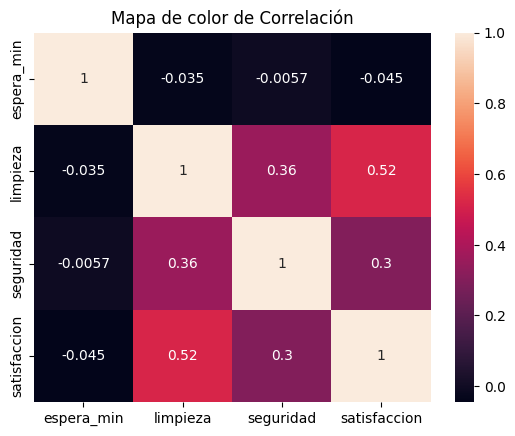

In [ ]:
#heatmap de algunas de los datos
sns.heatmap(dfv[['espera_min', 'limpieza', 'seguridad', 'satisfaccion']].corr(), annot = True)
plt.title("Mapa de color de Correlación")
plt.show()

# Relacion entre variables
##Con la funcion scatterplot podemos hacer una comparacion directa entre nuestras variables y ver como se relacionan por ejemplo:

###Empezamos con la relacion entre Dia y Region por satisfaccion, con esto podemos ver que los viajes a las regiones mas pupulares, en los dias mas concurridos suele tener una alta satisfaccion lo que indica que se tiene una muy buena organizacion cuando hay mucha gente, sin embargo tambien parece que los dias con menos afluencia de viajes se suelen confiar, pues esos dias presentan una satisfaccion baja


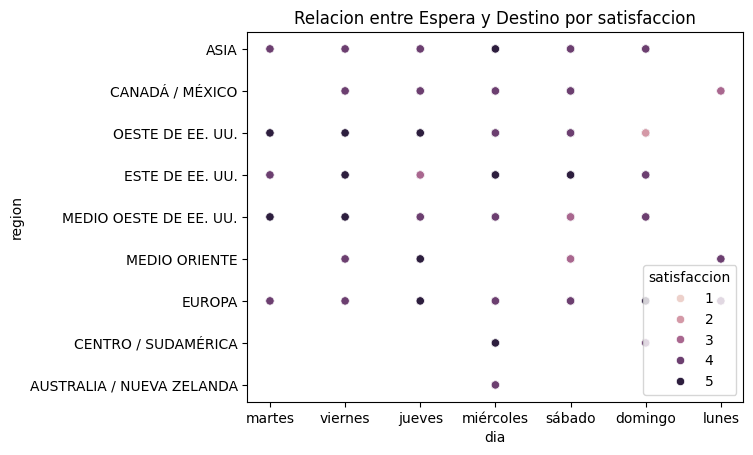

<Figure size 5000x4000 with 0 Axes>

In [ ]:
sns.scatterplot(x="dia",y="region",hue= "satisfaccion", data = dfv)
plt.title(f"Relacion entre Espera y Destino por satisfaccion")
plt.figure(figsize=(50, 40))
plt.show()

## La relacion entre dia y region por su area de abordaje
###Podemos observar que los dias martes y viernes por lo general los viajes hacia la region de Europa se hacen por la puerta 91-102, pero los jueves miercoles y sabado los viajes a la misma region se hacen por la puerta 1-12

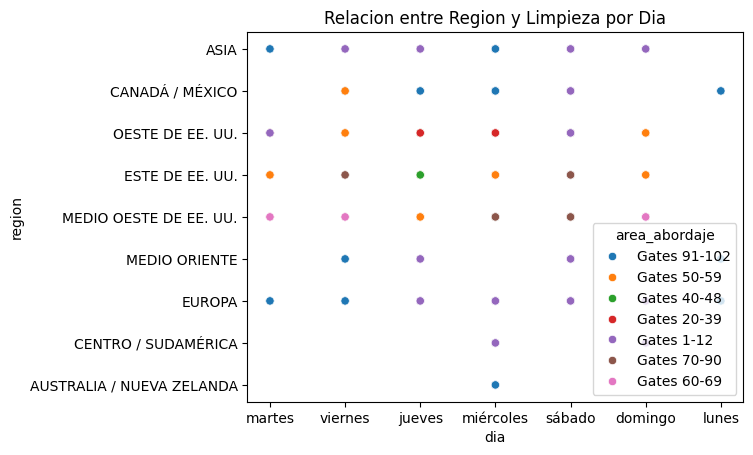

<Figure size 20000x40000 with 0 Axes>

In [ ]:
sns.scatterplot(x="dia",y="region",hue= "area_abordaje", data = dfv)
plt.title(f"Relacion entre Region y Limpieza por Dia")
plt.figure(figsize=(200, 400))
plt.show()

##Relacion por mapa
####En este tipo de grafica podemos ver la concentracion de todos nuestros datos, representandose como una linea con dos extenciones a los lados en cada punta, esta linea representa toda la cantidad de datos que tenemos, el cuadro enmedio es la zona donde hay una conglomeracion de los datos, y los puntos fuera de la grafica son los casos "atipicos", capturas que estan fuera de lo comun y fuera de la concentracion de datos, cabe destacar que estos casos Atipicos no son errores potenciales

####En esta parte podemos ver una grafica que tiene la relacion entre la region de los vuelos y los dias que estos se realizan, podemos observar que los martes se hacen mas viajes al este y oeste de EEUU, teniendo como caso atipico viajes a Asia y a Europa, caso contrario a los sbados , donde vemos que si se hacen mas viajes a estas regiones, al punto que incluso Europa esta dentro de la conglomeracion de datos


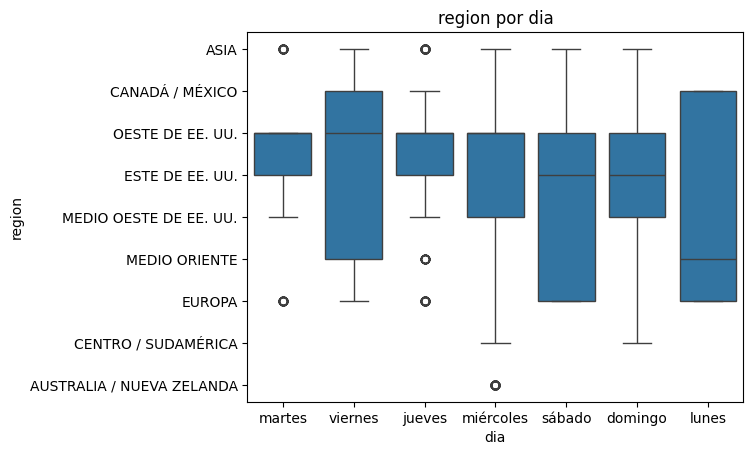

<Figure size 20000x40000 with 0 Axes>

In [ ]:
sns.boxplot(x="dia", y="region", data = dfv) #y region por limpieza
plt.title(f"region por dia")
plt.figure(figsize=(200, 400))
plt.show()

####Aqui podemos observar que la seguridad general todos los dias se mantiene en un nivel alto, entre 5 y 3 , siendo lo mas comun un nivel de 5 y 4, teniendo algunos casos atipicos de 1 y dos, esto nos dice que el nivel de seguridad es bastante alto

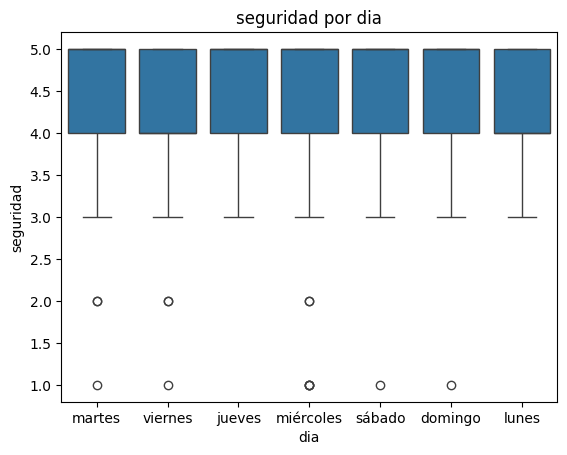

<Figure size 20000x40000 with 0 Axes>

In [ ]:
sns.boxplot(x="dia", y="seguridad", data = dfv) #y region por limpieza
plt.title(f"seguridad por dia")
plt.figure(figsize=(200, 400))
plt.show()

##Relacion de promedio
###En esta grafica de vela, nos permitira observar el promedio de uno de nuestros datos en relacion al otro, los datos llegan hasta donde marca la mecha de la vela, pero toda la concentracion de datos se muestra en la barra

###En esta grafica hicimos una comparacion de satisfaccion por la region, aqui podemos observar que en la region de medio oeste tiene un promedio de satisfaccion mas alto que los demas, aunque tambien podemos ver que la region Centro / Sudamerica la mecha es mas larga que los demas, lo que indica que en algun momento alguna medidas de satisfaccion fueron mas altas que los demas, pero el resto al ser mas bajas hizo que el promedio bajara


region
ASIA                         4.035242
AUSTRALIA / NUEVA ZELANDA    3.850000
CANADÁ / MÉXICO              3.959799
CENTRO / SUDAMÉRICA          4.045455
ESTE DE EE. UU.              4.055046
EUROPA                       3.857550
MEDIO OESTE DE EE. UU.       4.115538
MEDIO ORIENTE                4.072464
OESTE DE EE. UU.             4.015029
Name: satisfaccion, dtype: float64


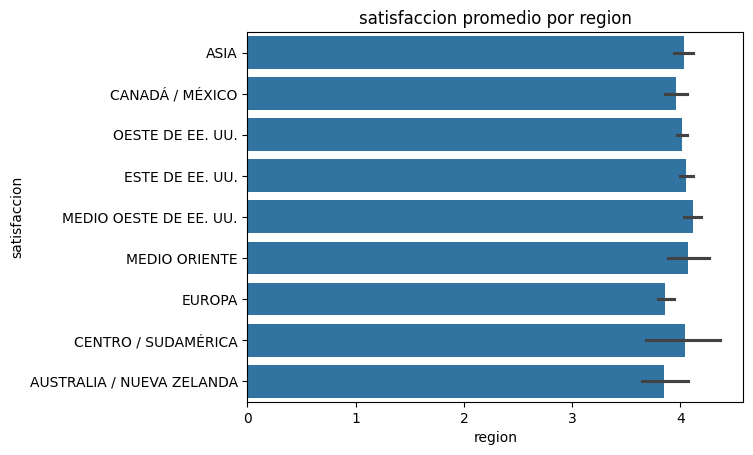

In [ ]:
print(dfv.groupby('region')['satisfaccion'].mean())
sns.barplot(x = "satisfaccion", y = "region", data = dfv)
plt.title(f"satisfaccion promedio por region")
plt.xlabel("region")
plt.ylabel("satisfaccion")
plt.show()

###Aqui los datos nos dicen que por promedio, los lunes tienen un tiempo de espera mas largo, en promedio 209 minutos, mientras que los martes tienen un tiempo de espera mas bajo, en promedio 147

dia
domingo      180.513109
jueves       153.842213
lunes        209.714286
martes       147.981168
miércoles    174.754826
sábado       163.728571
viernes      178.227642
Name: espera_min, dtype: float64


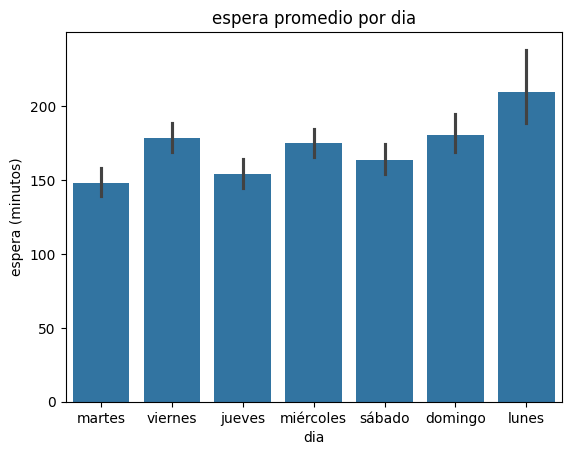

In [ ]:
print(dfv.groupby('dia')['espera_min'].mean())
sns.barplot(x = "dia", y ="espera_min" , data = dfv)
plt.title(f"espera promedio por dia")
plt.xlabel("dia")
plt.ylabel("espera (minutos)")
plt.show()

##Valores normalizados
###Vamos a sacar un valor promedio, este normalizara nuestra variables para que podamos observar un porcentaje adecuado de nuestras variables categoricas

###Aqui podemos ver que la puerta 1-12 tiene un porcentaje de casi 25% de abordaje, por lo que no solo es la mas utilizada sino que tambien es la que mas datos tiene en nuestro dataset

<ipython-input-27-f45c9f95b48d>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


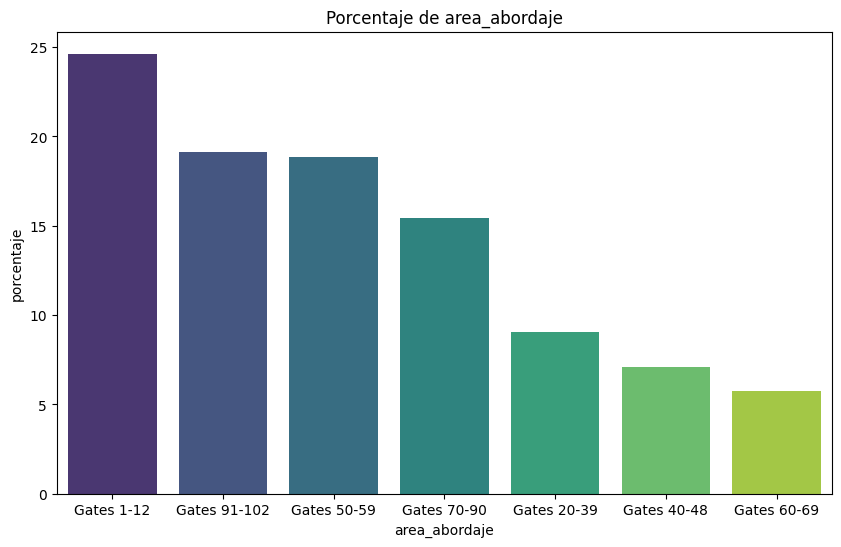

In [ ]:
v = 'area_abordaje'
plt.figure(figsize= (10,6))
#calcular porcentajes
#SELECT sexo, Count(*) FROM
value_counts = dfv[v].value_counts(normalize=True) * 100
sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")
plt.title(f"Porcentaje de {v}")
plt.xlabel(v)
plt.ylabel("porcentaje")
plt.show()

###Aqui podemos observar que el porcentaje de seguridad ocupa practicamente el 50% el nivel 5, asi que en general la seguridad es considerablemente alta, mientras que los niveles 1 o 2 son muy bajos, lo que nos dice que no hay muchos reportes de baja seguridad

<ipython-input-28-191bee10dfa6>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")


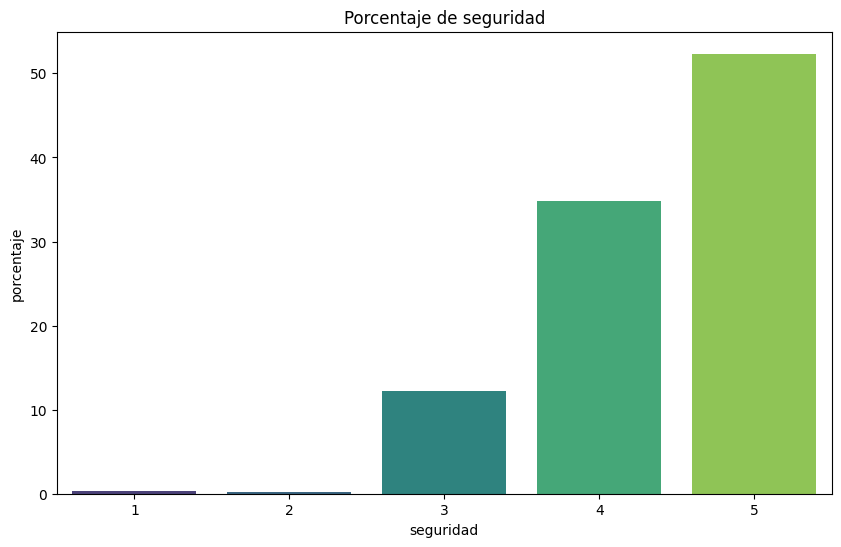

In [ ]:
v = 'seguridad'
plt.figure(figsize= (10,6))
#calcular porcentajes
#SELECT sexo, Count(*) FROM
value_counts = dfv[v].value_counts(normalize=True) * 100
sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")
plt.title(f"Porcentaje de {v}")
plt.xlabel(v)
plt.ylabel("porcentaje")
plt.show()